# AICE 모의고사 4회 - 기후 변화 예측

## 문제 시나리오

과거 기상 정보 및 환경 데이터를 분석 및 전처리한 후 머신러닝과 딥러닝으로 특정 지역의 연간 평균 기온을 변화를 예측하고 결과를 분석하세요.

---

## 4-1 | 라이브러리 임포트 및 데이터 로딩

### 【 문제 】

- 필요한 패키지를 임포트 pandas 라이브러리를 pd라는 별칭으로 임포트하고, 두 개의 데이터를 분석에 활용하는 코드를 작성하세요.
- climate_data.json 파일을 읽어 데이터프레임 변수 df_climate에 할당하세요.
- pollution_data.csv 파일을 읽어 데이터프레임 변수 df_pollution에 할당하세요.

In [16]:
import pandas as pd

df_climate = pd.read_json('./climate_data.json')
df_pollution = pd.read_csv('./pollution_data.csv')

## 4-2 | 데이터 병합 및 초기 탐색

### 【 문제 】

- 두 개의 데이터프레임(df_climate, df_pollution)을 LocationID와 Year 컬럼을 기준으로 병합하고, 병합된 데이터프레임의 상위 5개 행과 컬럼별 요약 정보를 출력하여 초기 데이터를 탐색하는 코드를 작성하세요.
- pandas의 merge 함수를 사용하여 df_climate와 df_pollution을 LocationID와 Year를 키(key)로 병합하고 df 변수에 저장하세요.
- 병합 방식은 inner로 지정하세요.
- df 데이터프레임의 상위 5개 행을 출력하세요.
- df 데이터프레임의 컬럼별 정보(dtype, Non-null Count)를 확인하세요.

In [17]:
df = pd.merge(df_climate, df_pollution, on=['LocationID', 'Year'], how='inner')

df.head()

,LocationID,Year,AvgTemperature_C,CO2_Concentration_ppm,SeaLevel_mm,ForestArea_percent,UrbanArea_percent,MajorEvent,PM25_ug_m3,Ozone_ppb,IndustrialEmissions_tons
0,16,2012,15.43,592,2.7,58.4,32.3,Flood,63.7,65.4,1488
1,8,2021,27.74,450,3.4,53.2,37.5,Flood,52.8,69.1,8099
2,17,2016,29.53,403,1.6,30.5,33.5,Storm,38.3,21.2,45298
3,5,2019,29.67,446,1.8,37.9,36.3,Storm,74.5,63.2,33376
4,5,2019,29.67,446,1.8,37.9,36.3,Storm,20.6,94.4,13329


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   LocationID                41 non-null     int64  
 1   Year                      41 non-null     int64  
 2   AvgTemperature_C          41 non-null     float64
 3   CO2_Concentration_ppm     41 non-null     int64  
 4   SeaLevel_mm               40 non-null     float64
 5   ForestArea_percent        41 non-null     float64
 6   UrbanArea_percent         41 non-null     float64
 7   MajorEvent                41 non-null     object 
 8   PM25_ug_m3                41 non-null     float64
 9   Ozone_ppb                 41 non-null     float64
 10  IndustrialEmissions_tons  41 non-null     int64  
dtypes: float64(6), int64(4), object(1)
memory usage: 3.7+ KB


## 4-3 | 범주형 변수 로트 시각화 및 데이터 경제

### 【 문제 】

- MajorEvent 컬럼의 분포를 시각화하고, 데이터 경제를 위해 'Unknown' 값을 가진 행을 제거하는 코드를 작성하세요.
- seaborn 라이브러리의 countplot을 사용하여 MajorEvent 컬럼의 분포를 시각화하세요.
- MajorEvent 컬럼 값이 'Unknown'인 행을 데이터프레임에서 삭제하세요.

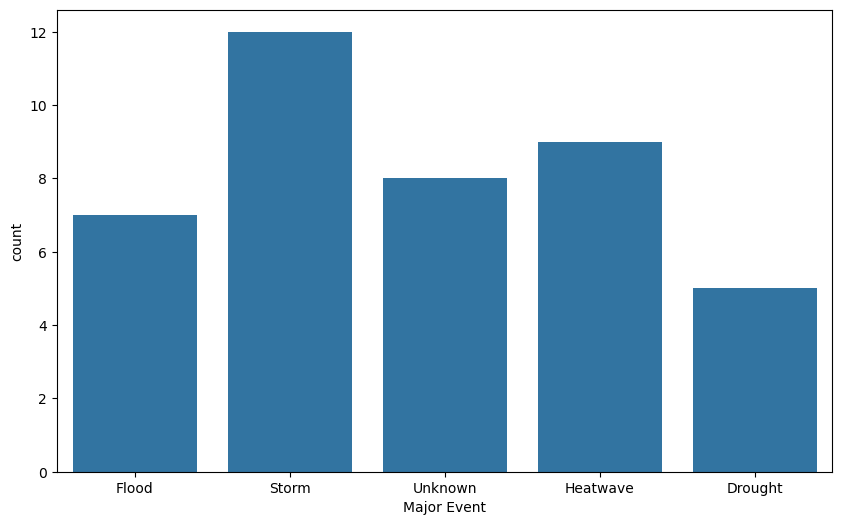

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='MajorEvent')
plt.xlabel('Major Event')
plt.show()

df = df[df['MajorEvent'] != 'Unknown'].copy()

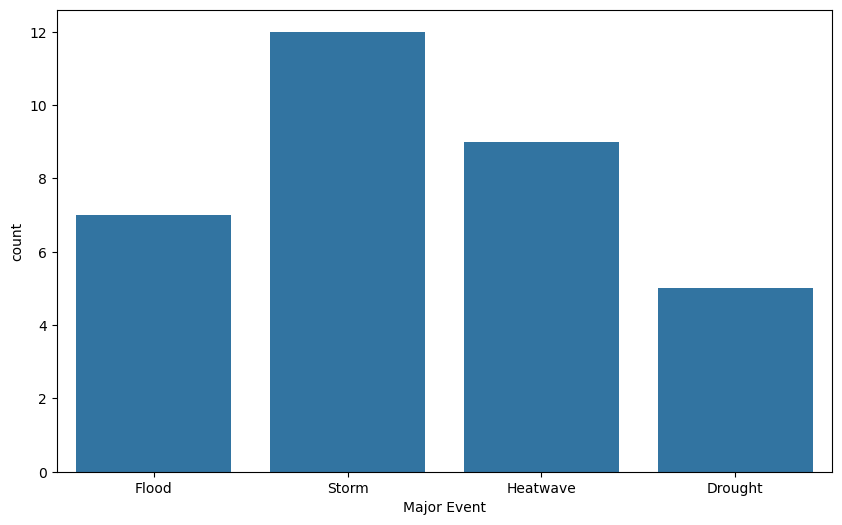

In [23]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='MajorEvent')
plt.xlabel('Major Event')
plt.show()

## 4-4 | 수치형 변수 관계 시각화 및 이상치 탐색

### 【 문제 】

- CO2_Concentration_ppm과 AvgTemperature_C 간의 관계를 jointplot으로 시각화하고, CO2_Concentration_ppm가 500 이상인 이상치를 찾아 행의 개수를 확인하는 코드를 작성하세요.
- seaborn 라이브러리의 jointplot을 사용하여 x축에 CO2_Concentration_ppm, y축에 AvgTemperature_C를 표시하세요.
- CO2_Concentration_ppm가 500 이상인 행의 개수를 세어 출력하세요.


<Figure size 1000x600 with 0 Axes>

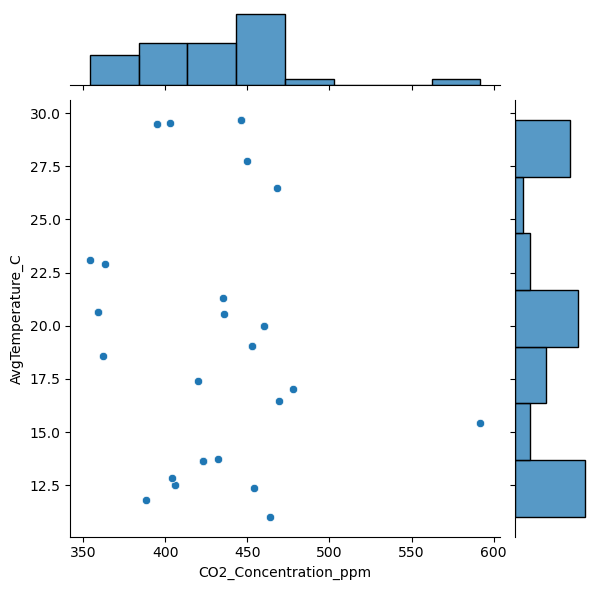

500 이상인 행의 개수 : 1


In [26]:
plt.figure(figsize=(10,6))
sns.jointplot(data=df, x='CO2_Concentration_ppm', y='AvgTemperature_C')
plt.show()

initial_row = df[df['CO2_Concentration_ppm'] >= 500].shape[0]
print(f'500 이상인 행의 개수 : {initial_row}')

## 4-5 | 이상치 및 불필요 컬럼 처리

### 【 문제 】

- CO2_Concentration_ppm가 500 이상인 이상치 행을 삭제하고, 모델링에 불필요한 LocationID와 Year 컬럼을 삭제하는 코드를 작성하세요.
- CO2_Concentration_ppm가 500 미만인 행만 남기고 데이터프레임을 업데이트하세요.
- LocationID와 Year 컬럼을 데이터프레임에서 삭제하세요.
- 변경된 데이터프레임을 df_cleaned에 저장하세요.


In [31]:
df = df[df['CO2_Concentration_ppm'] < 500].copy()

initial_row = df[df['CO2_Concentration_ppm'] >= 500].shape[0]
print(f'500 이상인 행의 개수 : {initial_row}')

df_cleaned = df.copy()
df_cleaned.info()

df_cleaned = df_cleaned.drop(columns=['LocationID', 'Year'])
df_cleaned.info()

500 이상인 행의 개수 : 0
<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, 1 to 40
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   LocationID                32 non-null     int64  
 1   Year                      32 non-null     int64  
 2   AvgTemperature_C          32 non-null     float64
 3   CO2_Concentration_ppm     32 non-null     int64  
 4   SeaLevel_mm               32 non-null     float64
 5   ForestArea_percent        32 non-null     float64
 6   UrbanArea_percent         32 non-null     float64
 7   MajorEvent                32 non-null     object 
 8   PM25_ug_m3                32 non-null     float64
 9   Ozone_ppb                 32 non-null     float64
 10  IndustrialEmissions_tons  32 non-null     int64  
dtypes: float64(6), int64(4), object(1)
memory usage: 3.0+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, 1 to 40
Data columns (total 9 columns):
 #   Colum

## 4-6 | 결측치 처리 및 데이터 타입 변환

### 【 문제 】

- 데이터프레임에 결측치가 있는지 확인하고, 결측치가 있는 행을 삭제한 뒤, SeaLevel_mm 컬럼을 정수형(int)으로 변환하세요.
- df_cleaned의 결측치를 확인하는 코드를 작성하세요.

In [40]:
print(f'결측치 확인 : \n{df_cleaned.isna().sum()}')
df_cleaned = df_cleaned.dropna().copy()

df_cleaned['SeaLevel_mm'] = df_cleaned['SeaLevel_mm'].astype(int)

df_cleaned.info()

결측치 확인 : 
AvgTemperature_C            0
CO2_Concentration_ppm       0
SeaLevel_mm                 0
ForestArea_percent          0
UrbanArea_percent           0
MajorEvent                  0
PM25_ug_m3                  0
Ozone_ppb                   0
IndustrialEmissions_tons    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, 1 to 40
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   AvgTemperature_C          32 non-null     float64
 1   CO2_Concentration_ppm     32 non-null     int64  
 2   SeaLevel_mm               32 non-null     int64  
 3   ForestArea_percent        32 non-null     float64
 4   UrbanArea_percent         32 non-null     float64
 5   MajorEvent                32 non-null     object 
 6   PM25_ug_m3                32 non-null     float64
 7   Ozone_ppb                 32 non-null     float64
 8   IndustrialEmissions_tons  32 non-null     int64  
dtype

## 4-7 | 불필요 컬럼 처리 및 범주형 변수 원-핫 인코딩

### 【 문제 】

- UrbanArea_percent 컬럼을 삭제하고, object 타입의 범주형 컬럼(MajorEvent)을 원-핫 인코딩하세요.
- df_processed에서 UrbanArea_percent 컬럼을 삭제하세요.
- pandas의 get_dummies 함수를 활용하여 object 타입의 컬럼에 대해 원-핫 인코딩을 수행하세요.
- 변경된 결과를 df_encoded 변수에 저장하세요.


In [44]:
df_processed = df_cleaned.drop('UrbanArea_percent', axis=1).copy()
# df_processed.info()

df_encoded = pd.get_dummies(data=df_processed, columns=['MajorEvent'])

df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, 1 to 40
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   AvgTemperature_C          32 non-null     float64
 1   CO2_Concentration_ppm     32 non-null     int64  
 2   SeaLevel_mm               32 non-null     int64  
 3   ForestArea_percent        32 non-null     float64
 4   PM25_ug_m3                32 non-null     float64
 5   Ozone_ppb                 32 non-null     float64
 6   IndustrialEmissions_tons  32 non-null     int64  
 7   MajorEvent_Drought        32 non-null     bool   
 8   MajorEvent_Flood          32 non-null     bool   
 9   MajorEvent_Heatwave       32 non-null     bool   
 10  MajorEvent_Storm          32 non-null     bool   
dtypes: bool(4), float64(4), int64(3)
memory usage: 3.2 KB


## 4-8 | 데이터 분리 및 스케일링

### 【 문제 】

- 최종 기온(AvgTemperature_C)을 예측하기 위해 데이터를 훈련 및 검증 데이터로 분리하고, 스케일링을 수행하세요.
- AvgTemperature_C 컬럼을 y 변수에, 나머지 컬럼을 X 변수에 할당하세요.
- scikit-learn의 train_test_split 함수를 사용하여 X와 y를 훈련 데이터(80%)와 검증 데이터(20%)으로 분리하세요. random_state는 42로 설정하세요.
- sklearn.preprocessing의 StandardScaler를 사용하여 훈련 데이터와의 Feature(X_train)를 스케일링하고 X_train_scaled에 할당하세요.
- StandardScaler의 transform 함수를 사용하여 검증 데이터와의 Feature(X_valid)를 스케일링하고 X_valid_scaled에 할당하세요.


In [52]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop('AvgTemperature_C', axis=1)
y = df_encoded['AvgTemperature_C']

ss = StandardScaler()

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_scaled = ss.fit_transform(X_train)
X_valid_scaled = ss.fit_transform(X_valid)

## 4-9 | 머신러닝 모델 학습(Random Forest Regressor)

### 【 문제 】

- scikit-learn의 RandomForestRegressor 모델을 생성하고 학습하세요.
- 모델의 n_estimators는 100, max_depth는 5, random_state는 42로 설정하세요.
- 모델을 rfr_model 변수에 저장하고, 훈련 데이터(X_train_scaled, y_train)으로 학습을 진행하세요.


In [53]:
from sklearn.ensemble import RandomForestRegressor

rfr_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rfr_model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 4-10 | 머신러닝 모델 학습(Support Vector Regressor)

### 【 문제 】

- scikit-learn의 SVR(Support Vector Regressor) 모델을 생성하고 학습하세요.
- 모델의 커널(kernel)은 rbf, C는 10, gamma는 auto로 설정하세요.
- 모델을 svr_model 변수에 저장하고, 훈련 데이터(X_train_scaled, y_train)으로 학습을 진행하세요.

In [55]:
from sklearn.svm import SVR

svr_model = SVR(kernel='rbf', C=10, gamma='auto')
svr_model.fit(X_train_scaled, y_train)

,kernel,'rbf'
,degree,3
,gamma,'auto'
,coef0,0.0
,tol,0.001
,C,10
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


## 4-11 | 머신러닝 모델 성능 평가(MAE 비교)

### 【 문제 】

- 두 머신러닝 모델(rfr_model, svr_model)의 성능을 검증 데이터를 사용하여 MAE(Mean Absolute Error)로 평가하고, 더 우수한 성능을 보인 모델의 이름을 answer11 변수에 저장하세요.
- rfr_model과 svr_model을 사용하여 검증 데이터(X_valid_scaled)에 대한 예측 값을 각각 rfr_pred, svr_pred에 저장하세요.
- scikit-learn의 mean_absolute_error 함수를 사용하여 두 모델의 MAE를 계산하고 각각 rfr_mae, svr_mae에 저장하세요.
- 두 MAE 값을 비교하여 더 작은 값을 가진 모델의 이름을 answer11 변수에 저장하세요(예: 'RandomForestRegressor', 'SVR')에 저장하세요.


In [62]:
from sklearn.metrics import mean_absolute_error

rfr_pred = rfr_model.predict(X_valid_scaled)
svr_pred = svr_model.predict(X_valid_scaled)

rfr_mae = mean_absolute_error(y_valid, rfr_pred)
svr_mae = mean_absolute_error(y_valid, svr_pred)

minium_mae = min(rfr_mae, svr_mae)

if minium_mae == rfr_mae:
    answer11 = 'RandomForestRegressor'
else:
    answer11 = 'SVR'

print(f'rfr_mae : {rfr_mae} / svr_mae : {svr_mae}')
print(f'더 작은 값을 가진 모델 : {answer11}')

rfr_mae : 7.9479660090703055 / svr_mae : 6.016833088064118
더 작은 값을 가진 모델 : SVR


## 4-12 | 딥러닝 모델 개발 및 학습

### 【 문제 】

- tensorflow.keras를 사용하여 AvgTemperature_C를 예측하는 딥러닝 모델을 만들고 학습하세요.
- 히든 레이어(Hidden Layer)를 2개 이상으로 구성하세요.
- Dropout 레이어를 1개 추가하고 비율을 0.2로 설정하세요.
- 손실 함수(loss function)는 mean_squared_error를 사용하세요.
- epochs는 30, batch_size는 16으로 설정하세요.
- 학습 과정에서 검증 데이터셋(X_valid_scaled, y_valid)을 사용하여 성능을 평가하고, 학습 정보를 history 변수에 저장하세요.

In [83]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dropout, Dense

dl_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

dl_model.compile(loss='mean_squared_error', metrics=['mse', 'mae'], optimizer='adam')

history = dl_model.fit(X_valid_scaled, y_valid, epochs=30, batch_size=16, validation_data=(X_valid_scaled, y_valid))

Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 954ms/step - loss: 316.6695 - mae: 17.3370 - mse: 316.6695 - val_loss: 315.2876 - val_mae: 17.3012 - val_mse: 315.2876
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 319.0453 - mae: 17.4016 - mse: 319.0453 - val_loss: 312.8571 - val_mae: 17.2314 - val_mse: 312.8571
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 315.8395 - mae: 17.3307 - mse: 315.8395 - val_loss: 310.4927 - val_mae: 17.1630 - val_mse: 310.4927
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 309.5815 - mae: 17.1654 - mse: 309.5815 - val_loss: 308.2463 - val_mae: 17.0977 - val_mse: 308.2463
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 307.8208 - mae: 17.0692 - mse: 307.8208 - val_loss: 306.0922 - val_mae: 17.0344 - val_mse: 306.0922
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 314.7818 - mae: 17.2852 - mse: 314.7818 - val_loss: 303.9997 - val_mae: 16.9725 - val_mse: 303.9997
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 

## 4-13 | 딥러닝 모델 학습 성능 시각화

### 【 문제 】

- matplotlib을 활용하여 딥러닝 모델의 학습 MSE와 검증 MSE를 그래프로 표시하고, 반복에 축 레이블을 추가하여 성능 변화를 시각화하세요.
- history 변수에 저장된 학습 MSE(loss)와 검증 MSE(val_loss)를 그래프로 그리세요.
- 각각의 변화를 'Training MSE'와 'Validation MSE'로 표시하세요.
- x축에 'Epochs', y축에 'MSE'라는 레이블을 지정하세요.


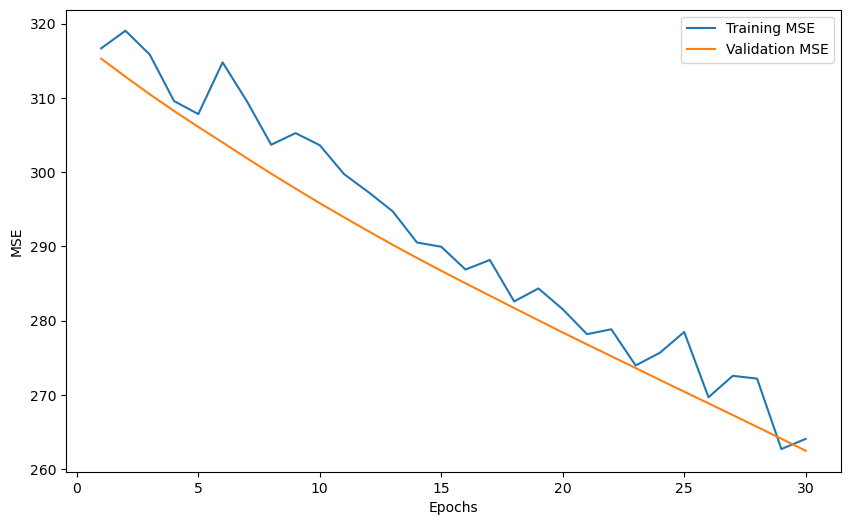

In [85]:
epochs = range(1, len(history.history['mse'])+1)

# print(history.history)

plt.figure(figsize=(10, 6))
plt.plot(epochs, history.history['mse'], label='Training MSE')
plt.plot(epochs, history.history['val_mse'], label='Validation MSE')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.show()

## 4-14 | 최종 모델 선택 및 결론 도출

### 【 문제 】

- 모델의 과적합(overfitting)을 방지하고 최적의 성능을 가진 모델을 자동으로 저장하기 위해 EarlyStopping과 ModelCheckpoint 콜백(callbacks)을 설정하여 모델을 학습하세요.

**EarlyStopping**
- monitor를 val_loss로 설정하여 검증 손실을 모니터링하세요.
- patience는 5로 설정하여 검증 손실이 5 에포크 동안 개선되지 않으면 학습을 중단하세요.
- restore_best_weights를 True로 설정하여 학습이 중단되었을 때 가장 좋은 성능을 보인 시점의 가중치를 복원하세요.

**ModelCheckpoint**
- filepath를 'best_model.h5'로 설정하여 최적의 모델을 해당 파일명으로 저장하세요.
- monitor는 val_loss로 설정하세요.
- save_best_only를 True로 설정하여 가장 좋은 성능을 보인 모델만 저장하세요.

In [89]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
mc = ModelCheckpoint(filepath='best_model.h5', monitor='val_loss', save_best_only=True)

history = dl_model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_valid_scaled, y_valid),
    callbacks=[es, mc]
)

Epoch 1/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 424.9050 - mae: 19.6000 - mse: 424.9050

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - loss: 436.7778 - mae: 19.9062 - mse: 436.7778 - val_loss: 259.2451 - val_mae: 15.6180 - val_mse: 259.2451
Epoch 2/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 453.3945 - mae: 20.2667 - mse: 453.3945

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 431.3917 - mae: 19.7878 - mse: 431.3917 - val_loss: 256.0393 - val_mae: 15.5151 - val_mse: 256.0393
Epoch 3/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 462.6842 - mae: 20.5269 - mse: 462.6842

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 426.7282 - mae: 19.6601 - mse: 426.7282 - val_loss: 252.8730 - val_mae: 15.4119 - val_mse: 252.8730
Epoch 4/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 415.4873 - mae: 19.4054 - mse: 415.4873

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 421.2599 - mae: 19.5288 - mse: 421.2599 - val_loss: 249.6038 - val_mae: 15.3044 - val_mse: 249.6038
Epoch 5/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 351.5631 - mae: 17.9707 - mse: 351.5631

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 416.3134 - mae: 19.4388 - mse: 416.3134 - val_loss: 246.3009 - val_mae: 15.1951 - val_mse: 246.3009
Epoch 6/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 457.7466 - mae: 20.5114 - mse: 457.7466

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 409.2570 - mae: 19.2228 - mse: 409.2570 - val_loss: 242.9523 - val_mae: 15.0830 - val_mse: 242.9523
Epoch 7/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 434.5700 - mae: 19.8465 - mse: 434.5700

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 406.0599 - mae: 19.1632 - mse: 406.0599 - val_loss: 239.5252 - val_mae: 14.9673 - val_mse: 239.5252
Epoch 8/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 386.7282 - mae: 18.7332 - mse: 386.7282

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 401.1157 - mae: 19.0124 - mse: 401.1157 - val_loss: 235.9197 - val_mae: 14.8448 - val_mse: 235.9197
Epoch 9/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 333.5538 - mae: 17.4137 - mse: 333.5538

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 400.3051 - mae: 19.0102 - mse: 400.3051 - val_loss: 232.1140 - val_mae: 14.7137 - val_mse: 232.1140
Epoch 10/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 369.9680 - mae: 18.0300 - mse: 369.9680

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 388.3582 - mae: 18.6862 - mse: 388.3582 - val_loss: 228.2029 - val_mae: 14.5769 - val_mse: 228.2029
Epoch 11/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 326.5443 - mae: 17.1990 - mse: 326.5443

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 384.5406 - mae: 18.6291 - mse: 384.5406 - val_loss: 224.2001 - val_mae: 14.4355 - val_mse: 224.2001
Epoch 12/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 356.5009 - mae: 17.9479 - mse: 356.5009

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 376.5275 - mae: 18.4291 - mse: 376.5275 - val_loss: 220.0956 - val_mae: 14.2886 - val_mse: 220.0956
Epoch 13/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 417.7785 - mae: 19.5373 - mse: 417.7785

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 376.9597 - mae: 18.4259 - mse: 376.9597 - val_loss: 215.8820 - val_mae: 14.1358 - val_mse: 215.8820
Epoch 14/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 374.6837 - mae: 18.3701 - mse: 374.6837

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 367.9396 - mae: 18.1589 - mse: 367.9396 - val_loss: 211.6004 - val_mae: 13.9780 - val_mse: 211.6004
Epoch 15/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 414.7392 - mae: 19.3560 - mse: 414.7392

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 361.3680 - mae: 18.0041 - mse: 361.3680 - val_loss: 207.1787 - val_mae: 13.8126 - val_mse: 207.1787
Epoch 16/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 303.0273 - mae: 16.4742 - mse: 303.0273

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 359.0911 - mae: 17.9078 - mse: 359.0911 - val_loss: 202.6424 - val_mae: 13.6405 - val_mse: 202.6424
Epoch 17/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 308.0491 - mae: 16.5878 - mse: 308.0491

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 343.0717 - mae: 17.5314 - mse: 343.0717 - val_loss: 198.0077 - val_mae: 13.4616 - val_mse: 198.0077
Epoch 18/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 387.7028 - mae: 18.6465 - mse: 387.7028

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 339.9083 - mae: 17.4254 - mse: 339.9083 - val_loss: 193.2726 - val_mae: 13.2754 - val_mse: 193.2726
Epoch 19/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 317.5852 - mae: 16.7816 - mse: 317.5852

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 328.8027 - mae: 17.1522 - mse: 328.8027 - val_loss: 188.4530 - val_mae: 13.0822 - val_mse: 188.4530
Epoch 20/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 304.9272 - mae: 16.6839 - mse: 304.9272

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 321.2029 - mae: 16.9737 - mse: 321.2029 - val_loss: 183.5142 - val_mae: 12.8813 - val_mse: 183.5142
Epoch 21/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 353.4155 - mae: 17.9150 - mse: 353.4155

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 311.1017 - mae: 16.6565 - mse: 311.1017 - val_loss: 178.4519 - val_mae: 12.6716 - val_mse: 178.4519
Epoch 22/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 370.2640 - mae: 18.4277 - mse: 370.2640

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 309.0444 - mae: 16.6383 - mse: 309.0444 - val_loss: 173.3134 - val_mae: 12.4545 - val_mse: 173.3134
Epoch 23/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 292.1361 - mae: 16.2208 - mse: 292.1361

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 301.9383 - mae: 16.3956 - mse: 301.9383 - val_loss: 168.1714 - val_mae: 12.2322 - val_mse: 168.1714
Epoch 24/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 277.1388 - mae: 15.7404 - mse: 277.1388

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 290.1161 - mae: 16.0527 - mse: 290.1161 - val_loss: 162.9104 - val_mae: 12.0000 - val_mse: 162.9104
Epoch 25/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 316.6272 - mae: 16.8208 - mse: 316.6272

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 289.1978 - mae: 15.9803 - mse: 289.1978 - val_loss: 157.5742 - val_mae: 11.7586 - val_mse: 157.5742
Epoch 26/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 317.4435 - mae: 16.9930 - mse: 317.4435

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 275.4244 - mae: 15.5626 - mse: 275.4244 - val_loss: 152.1920 - val_mae: 11.5101 - val_mse: 152.1920
Epoch 27/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 243.5755 - mae: 14.5721 - mse: 243.5755

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 259.9642 - mae: 15.0915 - mse: 259.9642 - val_loss: 146.7785 - val_mae: 11.2543 - val_mse: 146.7785
Epoch 28/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 227.2368 - mae: 14.0804 - mse: 227.2368

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 249.1393 - mae: 14.8315 - mse: 249.1393 - val_loss: 141.3098 - val_mae: 10.9874 - val_mse: 141.3098
Epoch 29/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 250.5029 - mae: 14.4253 - mse: 250.5029

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 254.7354 - mae: 14.8951 - mse: 254.7354 - val_loss: 135.8057 - val_mae: 10.7098 - val_mse: 135.8057
Epoch 30/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 259.9651 - mae: 15.0917 - mse: 259.9651

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 239.2547 - mae: 14.4635 - mse: 239.2547 - val_loss: 130.2688 - val_mae: 10.4236 - val_mse: 130.2688
Epoch 31/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 204.9530 - mae: 13.5588 - mse: 204.9530

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 230.1293 - mae: 14.1730 - mse: 230.1293 - val_loss: 124.7888 - val_mae: 10.1321 - val_mse: 124.7888
Epoch 32/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 199.5666 - mae: 12.9198 - mse: 199.5666

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 221.4441 - mae: 13.8086 - mse: 221.4441 - val_loss: 119.3214 - val_mae: 9.8305 - val_mse: 119.3214
Epoch 33/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 207.5880 - mae: 13.5944 - mse: 207.5880

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 224.1131 - mae: 13.8767 - mse: 224.1131 - val_loss: 113.9518 - val_mae: 9.5212 - val_mse: 113.9518
Epoch 34/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 246.6945 - mae: 14.8031 - mse: 246.6945

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 205.6825 - mae: 13.3902 - mse: 205.6825 - val_loss: 108.6976 - val_mae: 9.2035 - val_mse: 108.6976
Epoch 35/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 156.4547 - mae: 11.5904 - mse: 156.4547

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 187.5170 - mae: 12.7084 - mse: 187.5170 - val_loss: 103.5925 - val_mae: 8.9256 - val_mse: 103.5925
Epoch 36/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 185.7122 - mae: 12.7857 - mse: 185.7122

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 171.2613 - mae: 12.1974 - mse: 171.2613 - val_loss: 98.5269 - val_mae: 8.7419 - val_mse: 98.5269
Epoch 37/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 180.9992 - mae: 12.2252 - mse: 180.9992

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 169.2363 - mae: 11.9988 - mse: 169.2363 - val_loss: 93.6255 - val_mae: 8.5557 - val_mse: 93.6255
Epoch 38/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 157.9609 - mae: 11.4139 - mse: 157.9609

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 158.9839 - mae: 11.4806 - mse: 158.9839 - val_loss: 88.8636 - val_mae: 8.3636 - val_mse: 88.8636
Epoch 39/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 139.8320 - mae: 10.6177 - mse: 139.8320

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - loss: 151.3651 - mae: 11.1898 - mse: 151.3651 - val_loss: 84.3125 - val_mae: 8.1706 - val_mse: 84.3125
Epoch 40/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 121.5020 - mae: 9.9009 - mse: 121.5020

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 140.2538 - mae: 10.6131 - mse: 140.2538 - val_loss: 79.9631 - val_mae: 7.9753 - val_mse: 79.9631
Epoch 41/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 147.4720 - mae: 11.1825 - mse: 147.4720

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 134.3482 - mae: 10.5115 - mse: 134.3482 - val_loss: 75.8338 - val_mae: 7.7776 - val_mse: 75.8338
Epoch 42/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 119.5133 - mae: 9.6572 - mse: 119.5133

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 122.0541 - mae: 9.8903 - mse: 122.0541 - val_loss: 71.9626 - val_mae: 7.5782 - val_mse: 71.9626
Epoch 43/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 136.7068 - mae: 10.7133 - mse: 136.7068

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 120.0794 - mae: 9.8673 - mse: 120.0794 - val_loss: 68.3000 - val_mae: 7.3736 - val_mse: 68.3000
Epoch 44/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 133.0275 - mae: 10.2303 - mse: 133.0275

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 108.5114 - mae: 9.3021 - mse: 108.5114 - val_loss: 64.9178 - val_mae: 7.1694 - val_mse: 64.9178
Epoch 45/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 127.4019 - mae: 10.3906 - mse: 127.4019

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 101.0324 - mae: 9.0431 - mse: 101.0324 - val_loss: 61.8725 - val_mae: 6.9660 - val_mse: 61.8725
Epoch 46/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 79.0740 - mae: 7.8983 - mse: 79.0740

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 79.8611 - mae: 7.9900 - mse: 79.8611 - val_loss: 59.0854 - val_mae: 6.7613 - val_mse: 59.0854
Epoch 47/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 97.3404 - mae: 8.6046 - mse: 97.3404

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 89.8759 - mae: 8.1840 - mse: 89.8759 - val_loss: 56.5980 - val_mae: 6.5553 - val_mse: 56.5980
Epoch 48/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 97.1093 - mae: 9.2441 - mse: 97.1093

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 76.5846 - mae: 7.6942 - mse: 76.5846 - val_loss: 54.4215 - val_mae: 6.3480 - val_mse: 54.4215
Epoch 49/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 69.2455 - mae: 7.3814 - mse: 69.2455

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 69.7020 - mae: 7.2674 - mse: 69.7020 - val_loss: 52.5884 - val_mae: 6.1445 - val_mse: 52.5884
Epoch 50/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 51.7516 - mae: 5.8560 - mse: 51.7516

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 63.3350 - mae: 6.7524 - mse: 63.3350 - val_loss: 51.0646 - val_mae: 5.9403 - val_mse: 51.0646
Epoch 51/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 78.0934 - mae: 8.0295 - mse: 78.0934

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 72.9551 - mae: 7.4638 - mse: 72.9551 - val_loss: 49.8081 - val_mae: 5.7313 - val_mse: 49.8081
Epoch 52/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 42.8325 - mae: 5.6958 - mse: 42.8325

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 51.8330 - mae: 6.1431 - mse: 51.8330 - val_loss: 48.8229 - val_mae: 5.6302 - val_mse: 48.8229
Epoch 53/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 43.7026 - mae: 5.7306 - mse: 43.7026

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 59.9147 - mae: 6.7118 - mse: 59.9147 - val_loss: 48.0857 - val_mae: 5.5448 - val_mse: 48.0857
Epoch 54/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 45.9596 - mae: 5.5796 - mse: 45.9596

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 40.4220 - mae: 5.3073 - mse: 40.4220 - val_loss: 47.6681 - val_mae: 5.4636 - val_mse: 47.6681
Epoch 55/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 47.4113 - mae: 5.7790 - mse: 47.4113

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 42.1995 - mae: 5.5314 - mse: 42.1995 - val_loss: 47.4548 - val_mae: 5.3817 - val_mse: 47.4548
Epoch 56/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 45.7765 - mae: 5.8242 - mse: 45.7765

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 41.0264 - mae: 5.4307 - mse: 41.0264 - val_loss: 47.3819 - val_mae: 5.2956 - val_mse: 47.3819
Epoch 57/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 27.3018 - mae: 4.4412 - mse: 27.3018 - val_loss: 47.4760 - val_mae: 5.2737 - val_mse: 47.4760
Epoch 58/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 25.9354 - mae: 4.2987 - mse: 25.9354 - val_loss: 47.7531 - val_mae: 5.2755 - val_mse: 47.7531
Epoch 59/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 31.1466 - mae: 4.5301 - mse: 31.1466 - val_loss: 48.1980 - val_mae: 5.2774 - val_mse: 48.1980
Epoch 60/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 31.0934 - mae: 4.5334 - mse: 31.0934 - val_loss: 48.7383 - val_mae: 5.2778 - val_mse: 48.7383
Epoch 61/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 26.2747 - mae: 4.0297 - mse: 26.2747 - val_loss: 49.4461 - val_mae: 5.2816 - val_mse: 49.4461
